# Laboratorio de detección facial de visión artificial: Cuaderno del estudiante

En este laboratorio, usará Amazon Rekognition para realizar una detección facial de un rostro conocido.

Los pasos generales que realizará en este laboratorio son los siguientes:

1. Crear una colección.

2. Cargar una imagen de un rostro que desee detectar en el cuaderno de Amazon SageMaker.

3. Agregar la imagen a la colección.

4. Ver el cuadro de delimitación que se creó para la imagen.

5. Enumerar los rostros en la colección.

6. Utilizar la colección para encontrar un rostro.

7. Ver el cuadro delimitador del rostro que se encontró.

8. Eliminar la colección.

---

## Importación de paquetes de Python

Empiece por importar los paquetes Python que necesita.

En el siguiente código:

- *matplotlib* proporciona funciones de trazado
- *skimage* representa scikit-image, que proporciona varias herramientas útiles de manipulación de imágenes
- *boto3* representa el AWS SDK para Python (Boto3), que es la biblioteca de Python para AWS
- *numpy* representa NumPy, que es una biblioteca para manipular datos
- *PIL* representa la biblioteca de imágenes de Python, que contiene un conjunto de herramientas para dibujar imágenes


In [31]:
from skimage import io
# Importa el módulo `io` de la librería `skimage` para manejar imágenes (lectura y escritura).
import os

from skimage.transform import rescale
# Importa la función `rescale` de `skimage.transform`, que permite redimensionar imágenes manteniendo la proporción.

from matplotlib import pyplot as plt
# Importa el módulo `pyplot` de `matplotlib`, usado para crear gráficos y mostrar imágenes.

import boto3
# Importa la librería `boto3`, que es el SDK de Python para interactuar con servicios de AWS (como Rekognition).

import numpy as np
# Importa la librería `numpy`, que se utiliza para realizar operaciones matemáticas y manejar arrays de manera eficiente.

from PIL import Image, ImageDraw, ImageColor, ImageOps
# Importa clases de la librería `Pillow` (PIL):
# - `Image`: para cargar y manejar imágenes.
# - `ImageDraw`: para dibujar formas (como rectángulos) sobre imágenes.
# - `ImageColor`: para manejar colores en diferentes formatos.
# - `ImageOps`: para realizar operaciones como bordes y reflejos en imágenes.


## Tarea 1: crear una colección

En esta tarea, creará una colección en Amazon Rekognition.

Solo debe ejecutar este paso una vez.


In [32]:
client = boto3.client('rekognition')
# Crea un cliente para interactuar con el servicio de Amazon Rekognition usando Boto3.
# Este cliente permite llamar a las APIs de Rekognition para realizar operaciones como crear colecciones, detectar rostros, etc.

collection_id = 'Collection'
# Define un identificador único para la colección de imágenes que deseas crear.
# Este identificador será el nombre de tu colección en Rekognition.
# NOTA DE JANU: Si queremos cambiar la collection debemos cambiar el ID

print(f"Intentando crear o verificar la colección con ID: {collection_id}")
# Imprime el nombre de la colección que estamos manejando, para que los alumnos sepan cuál estamos procesando.

# Verificar si la colección ya existe
existing_collections = client.list_collections()['CollectionIds']
# Llama a la API `list_collections` de Rekognition para obtener una lista de todas las colecciones existentes.
# La respuesta es un diccionario, y `CollectionIds` contiene una lista de los nombres de las colecciones.

if collection_id in existing_collections:
    # Comprueba si el ID de la colección que deseas crear ya está en la lista de colecciones existentes.
    print(f"La colección '{collection_id}' ya existe.")
    # Si la colección ya existe, se imprime un mensaje y no se intenta crearla nuevamente.
else:
    # Crear la colección si no existe
    response = client.create_collection(CollectionId=collection_id)
    # Llama a la API `create_collection` para crear una nueva colección con el ID especificado.
    # Si la colección se crea exitosamente, AWS devuelve un ARN (Amazon Resource Name) y un código de estado.

    print('Collection ARN: ' + response['CollectionArn'])
    # Imprime el ARN de la colección recién creada.
    # El ARN es un identificador único que AWS asigna a los recursos creados.

    print('Status Code: ' + str(response['StatusCode']))
    # Imprime el código de estado de la operación. Un código `200` indica que la colección se creó exitosamente.

    print('La colección se creó exitosamente.')
    # Indica que el proceso de creación de la colección ha finalizado.

print('Done...')
# Muestra un mensaje general indicando que el script terminó su ejecución.



Intentando crear o verificar la colección con ID: Collection
La colección 'Collection' ya existe.
Done...


## Tarea 2: cargar una imagen para buscar

Use la imagen de muestra provista, con el nombre *mum.jpg*, y cárguela en este cuaderno.

Luego, mire la imagen ejecutando la celda.


<h1 style="color:purple;">NOTAS DE JANU</h1>

Si cambiamos el filename podemos elegir cualquier imagen como modelo. En este caso estoy usando model.png con una imagen mia para demo


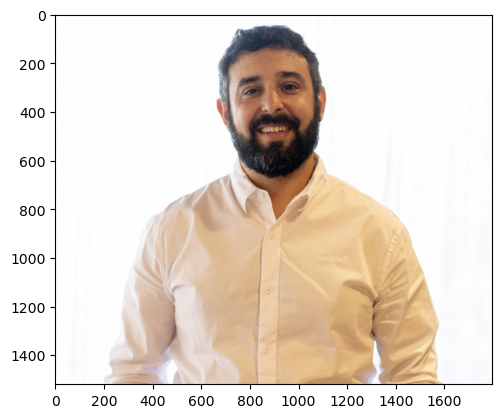

In [33]:
filename = "model.png"
# Define el nombre del archivo de imagen que deseas cargar.
# En este caso, "mum.jpg" es el archivo que contiene la imagen que se utilizará.

faceimage = io.imread(filename)
# Carga la imagen desde el archivo usando la función `imread` del módulo `skimage.io`.
# La imagen se lee como un array de NumPy, lo que permite procesarla de manera eficiente.

plt.imshow(faceimage)
# Muestra la imagen cargada usando `imshow` del módulo `matplotlib.pyplot`.
# Esto renderiza la imagen en una ventana gráfica o directamente en la notebook.



Asegúrese de que el tamaño de la imagen sea menos de 4096 x 4096 píxeles. Si la imagen tiene un tamaño mayor, debe ajustarlo con el siguiente código:

`faceimage = rescale(faceimage, 0.50, mode='constant')`

**Nota:** El valor numérico representa el factor según el que se debe escalar. Un valor de *0.5* escalará la imagen a un 50 por ciento de la original.

Cuando se ajuste el tamaño de la imagen, guarde el archivo.

`io.imsave(filename, faceimage)`

**Sugerencia:** Debe copiar el código en una celda de código y ejecutarla.


## Tarea 3: agregar la imagen a la colección

Agregue la imagen a la colección que creó anteriormente.


In [34]:
externalimageid = filename
# Asigna el nombre del archivo de imagen como el identificador externo para el rostro en la colección.

# Verificar si el rostro ya está indexado en la colección
response = client.list_faces(CollectionId=collection_id)
# Obtiene una lista de los rostros indexados en la colección.

faces = response['Faces']
# Extrae la lista de rostros desde la respuesta.

found = False
# Variable para rastrear si el rostro ya está indexado.

for face in faces:
    # Itera sobre los rostros existentes en la colección.
    if face['ExternalImageId'] == externalimageid:
        # Compara el ExternalImageId de cada rostro con el del archivo actual.
        found = True
        print(f"El rostro con ExternalImageId '{externalimageid}' ya está indexado con FaceId: {face['FaceId']}.")
        break
        # Si encuentra el rostro, lo indica y detiene la búsqueda.

if not found:
    # Si el rostro no está indexado, procede a indexarlo.
    with open(filename, 'rb') as fimage:
        # Abre el archivo de imagen en modo de lectura binaria.
        response = client.index_faces(CollectionId=collection_id,
                                      Image={'Bytes': fimage.read()},
                                      # Proporciona la imagen como un objeto binario (bytes) para Rekognition.
                                      ExternalImageId=externalimageid,
                                      # Asigna el identificador externo a este rostro en la colección.
                                      MaxFaces=1,
                                      # Indica que solo se indexará un rostro de la imagen.
                                      QualityFilter="AUTO",
                                      # Ajusta automáticamente la calidad de la imagen para mejorar la detección.
                                      DetectionAttributes=['ALL'])
                                      # Solicita todas las posibles características detectadas en el rostro.

    print('Results for ' + filename)
    # Imprime un mensaje con el nombre del archivo procesado.

    print('Faces indexed:')
    # Imprime los rostros que fueron indexados exitosamente.
    for faceRecord in response['FaceRecords']:
        # Itera sobre los registros de rostros indexados en la respuesta.
        print('  Face ID: ' + faceRecord['Face']['FaceId'])
        # Imprime el ID único del rostro indexado.
        print('  Location: {}'.format(faceRecord['Face']['BoundingBox']))
        # Imprime la ubicación del rostro en la imagen original usando un bounding box.

    print('Faces not indexed:')
    # Imprime información sobre los rostros que no pudieron ser indexados.
    for unindexedFace in response['UnindexedFaces']:
        # Itera sobre los rostros no indexados en la respuesta.
        print(' Location: {}'.format(unindexedFace['FaceDetail']['BoundingBox']))
        # Imprime la ubicación del rostro no indexado en la imagen original.
        print(' Reasons:')
        # Imprime las razones por las cuales el rostro no fue indexado.
        for reason in unindexedFace['Reasons']:
            # Itera sobre la lista de razones para el rostro no indexado.
            print('   ' + reason)
            # Imprime cada razón.


El rostro con ExternalImageId 'model.png' ya está indexado con FaceId: eae27946-cc03-4b8e-9be9-24b29a4e261c.


<h1 style="color:purple;">NOTAS DE JANU</h1>

# Explicación del tamaño del cuadro verde en Rekognition

El tamaño del cuadro verde que indica dónde está el rostro lo determina **Amazon Rekognition**, y lo devuelve como parte de la respuesta en la propiedad `BoundingBox`. Este `BoundingBox` contiene las **dimensiones normalizadas** (es decir, valores entre 0 y 1) que indican la ubicación del rostro dentro de la imagen.

## ¿Cómo se calcula el tamaño del cuadro?

El `BoundingBox` incluye cuatro valores:

- **`Width`**: Ancho del cuadro, como fracción del ancho total de la imagen.
- **`Height`**: Alto del cuadro, como fracción del alto total de la imagen.
- **`Left`**: Coordenada X del lado izquierdo del cuadro, como fracción del ancho total de la imagen.
- **`Top`**: Coordenada Y del borde superior del cuadro, como fracción del alto total de la imagen.

Para convertir estas dimensiones normalizadas en **píxeles** (coordenadas reales dentro de la imagen), necesitas multiplicarlas por el ancho y alto de la imagen en píxeles.

Por ejemplo:

- **Coordenada X inicial del cuadro**: `Left * ancho_imagen`
- **Coordenada Y inicial del cuadro**: `Top * alto_imagen`
- **Ancho del cuadro en píxeles**: `Width * ancho_imagen`
- **Alto del cuadro en píxeles**: `Height * alto_imagen`

Esto te permitirá representar correctamente el cuadro en la imagen procesada.



## Tarea 4: ver el cuadro delimitador para el rostro detectado

Si se encuentra un rostro, los resultados deben incluir la ubicación del rostro que se detectó. Examine el cuadro delimitador en la imagen.

Para ello, use la biblioteca PIL, que importó anteriormente en este laboratorio. Al extraer BoundingBox, puede dibujar un conjunto de líneas alrededor de la imagen.


El rostro con ExternalImageId 'model.png' ya está indexado con FaceId: eae27946-cc03-4b8e-9be9-24b29a4e261c.


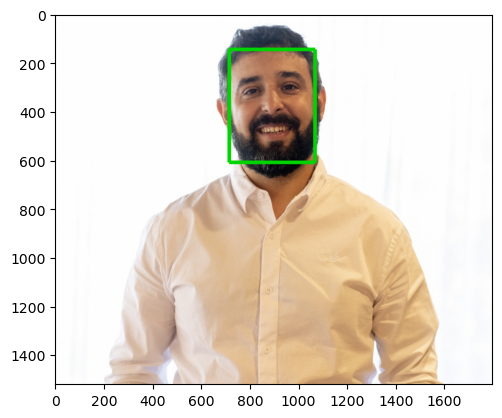

In [35]:
# Obtener la lista de rostros en la colección
response = client.list_faces(CollectionId=collection_id)
# Obtiene una lista de los rostros indexados en la colección.

faces = response['Faces']
# Extrae la lista de rostros desde la respuesta.

# Verificar si el rostro ya está indexado
found = False
bounding_box = None  # Variable para almacenar el BoundingBox

for face in faces:
    if face['ExternalImageId'] == externalimageid:
        # Si encuentra el rostro, guarda el BoundingBox y detiene la búsqueda
        found = True
        bounding_box = face['BoundingBox']
        print(f"El rostro con ExternalImageId '{externalimageid}' ya está indexado con FaceId: {face['FaceId']}.")
        break

if not found:
    print(f"El rostro con ExternalImageId '{externalimageid}' no está indexado.")
else:
    # Dibujar el cuadro en la imagen
    img = Image.open(filename)
    imgWidth, imgHeight = img.size

    draw = ImageDraw.Draw(img)

    # Calcular las coordenadas del BoundingBox en píxeles
    left = imgWidth * bounding_box['Left']
    top = imgHeight * bounding_box['Top']
    width = imgWidth * bounding_box['Width']
    height = imgHeight * bounding_box['Height']

    points = ((left, top), (left + width, top), (left + width, top + height), (left, top + height), (left, top))
    draw.line(points, fill='#00d400', width=15)

    # Mostrar la imagen con el cuadro dibujado
    plt.imshow(img)
    plt.show()


## Tarea 5: enumerar los rostros en la colección

Examine la imagen que tiene en la colección. 



In [36]:
maxResults = 2
# Define la cantidad máxima de rostros que se recuperarán por cada solicitud a la colección.
# Esto es útil si la colección contiene muchos rostros, ya que los resultados se paginan.

faces_count = 0
# Inicializa un contador para rastrear la cantidad total de rostros en la colección.

tokens = True
# Variable de control para determinar si hay más páginas de resultados.

response = client.list_faces(CollectionId=collection_id, MaxResults=maxResults)
# Realiza la primera solicitud para listar los rostros en la colección, con el límite definido por `maxResults`.

print('Faces in collection ' + collection_id)
# Imprime un encabezado indicando que se listarán los rostros en la colección.

while tokens:
    # Bucle para manejar la paginación de resultados.

    faces = response['Faces']
    # Extrae la lista de rostros de la respuesta actual.

    for face in faces:
        # Itera sobre cada rostro en la lista actual.
        print(face)
        # Imprime la información del rostro actual (detalles como FaceId, BoundingBox, ExternalImageId, etc.).
        faces_count += 1
        # Incrementa el contador de rostros.

    if 'NextToken' in response:
        # Verifica si la respuesta contiene un token para la siguiente página de resultados.
        nextToken = response['NextToken']
        # Obtiene el token para la próxima página.
        response = client.list_faces(CollectionId=collection_id, NextToken=nextToken, MaxResults=maxResults)
        # Realiza la solicitud para la próxima página utilizando el token.
    else:
        tokens = False
        # Si no hay un token para la próxima página, termina el bucle.

print(f'Total faces in collection: {faces_count}')
# Imprime el total de rostros encontrados en la colección después de recorrer todas las páginas.


Faces in collection Collection
{'FaceId': 'eae27946-cc03-4b8e-9be9-24b29a4e261c', 'BoundingBox': {'Width': 0.19594399631023407, 'Height': 0.3055869936943054, 'Left': 0.3977850079536438, 'Top': 0.09550490230321884}, 'ImageId': '888b5866-770b-32bd-ac56-f40353d66734', 'ExternalImageId': 'model.png', 'Confidence': 99.99739837646484, 'IndexFacesModelVersion': '7.0'}
Total faces in collection: 1


## Tarea 6: encontrar un rostro usando la colección

En este paso, usará la colección para detectar un rostro en una imagen.

Use la imagen de muestra provista, con el nombre *target.jpg*, y cárguela en este cuaderno.



Procesando la imagen: 20240522_185606.jpg


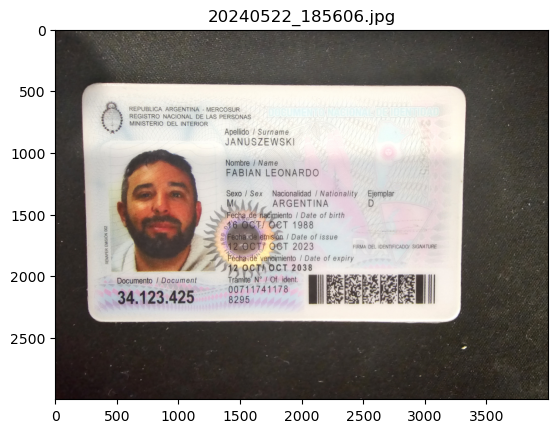

Procesando la imagen: IMG_20170706_112204487.jpg


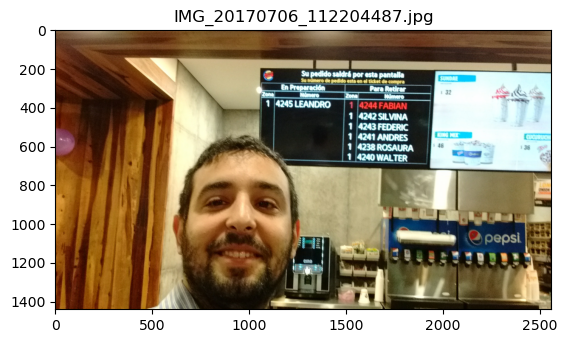

Procesando la imagen: janu_re.png


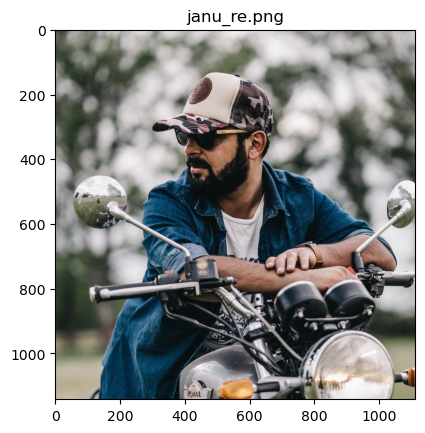

Procesando la imagen: janu_traje.jpg


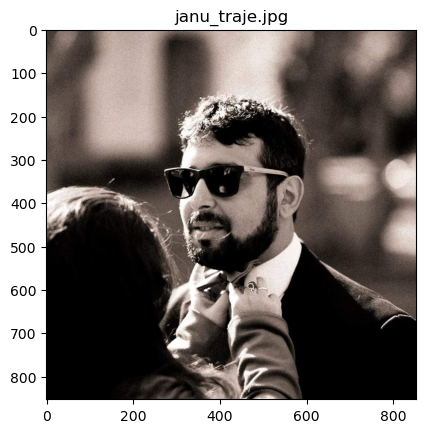

In [43]:
# Obtiene el path actual donde se encuentra el script
current_directory = os.getcwd()

# Define la carpeta donde están las imágenes
images_folder = os.path.join(current_directory, "images")

# Lista todos los archivos en la carpeta "images"
image_files = [f for f in os.listdir(images_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
# Filtra los archivos para incluir solo imágenes con extensiones válidas.

# Procesa cada imagen en la carpeta
for targetfilename in image_files:
    targetfilepath = os.path.join(images_folder, targetfilename)
    # Construye la ruta completa para cada archivo de imagen.

    print(f"Procesando la imagen: {targetfilename}")
    # Imprime el nombre de la imagen que se está procesando.

    targetimage = Image.open(targetfilepath)
    # Abre el archivo de imagen actual utilizando Pillow (PIL).

    plt.imshow(targetimage)
    plt.title(targetfilename)  # Agrega el nombre del archivo como título
    plt.show()
    # Muestra la imagen cargada utilizando Matplotlib.


A continuación, llame la operación `search_faces_by_image` y vea si obtiene una coincidencia.

In [44]:
threshold = 70
# Define el umbral de similitud para considerar un rostro como coincidencia.
# Solo se devolverán coincidencias con una similitud igual o superior al 70%.

maxFaces = 2
# Define el número máximo de coincidencias de rostros que se devolverán en la respuesta.

# Iterar sobre todas las imágenes en la carpeta
for targetfilename in image_files:
    targetfilepath = os.path.join(images_folder, targetfilename)
    # Construye la ruta completa de la imagen actual.

    print(f"\nBuscando coincidencias para la imagen: {targetfilename}")
    # Imprime el nombre de la imagen que está siendo procesada.

    with open(targetfilepath, 'rb') as timage:
        # Abre el archivo de la imagen en modo de lectura binaria.

        response2 = client.search_faces_by_image(
            CollectionId=collection_id,
            # Especifica la colección en la que se buscarán las coincidencias.
            Image={'Bytes': timage.read()},
            # Proporciona la imagen como un objeto binario para que Rekognition procese y compare el rostro.
            FaceMatchThreshold=threshold,
            # Define el umbral de similitud mínimo para considerar un rostro como coincidencia.
            MaxFaces=maxFaces
            # Limita la cantidad de coincidencias de rostros que se devolverán.
        )

    faceMatches = response2.get('FaceMatches', [])
    # Extrae la lista de coincidencias de rostros devuelta en la respuesta. Si no hay coincidencias, devuelve una lista vacía.

    if not faceMatches:
        # Si no se encontraron coincidencias, imprime un mensaje.
        print(f"No se encontraron coincidencias para la imagen: {targetfilename}")
    else:
        print('Matching faces:')
        # Imprime un encabezado indicando que se mostrarán las coincidencias.

        for match in faceMatches:
            # Itera sobre las coincidencias encontradas en la respuesta.

            print('  FaceId: ' + match['Face']['FaceId'])
            # Imprime el ID único del rostro coincidente en la colección.

            print('  Similarity: ' + "{:.2f}".format(match['Similarity']) + "%")
            # Imprime el porcentaje de similitud entre el rostro objetivo y el rostro coincidente.

            print('  ExternalImageId: ' + match['Face']['ExternalImageId'])
            # Imprime el identificador externo (por ejemplo, nombre de archivo) del rostro coincidente.

            print()
            # Imprime una línea en blanco para separar las coincidencias.



Buscando coincidencias para la imagen: 20240522_185606.jpg
Matching faces:
  FaceId: eae27946-cc03-4b8e-9be9-24b29a4e261c
  Similarity: 99.97%
  ExternalImageId: model.png


Buscando coincidencias para la imagen: IMG_20170706_112204487.jpg
Matching faces:
  FaceId: eae27946-cc03-4b8e-9be9-24b29a4e261c
  Similarity: 100.00%
  ExternalImageId: model.png


Buscando coincidencias para la imagen: janu_re.png
Matching faces:
  FaceId: eae27946-cc03-4b8e-9be9-24b29a4e261c
  Similarity: 98.75%
  ExternalImageId: model.png


Buscando coincidencias para la imagen: janu_traje.jpg
Matching faces:
  FaceId: eae27946-cc03-4b8e-9be9-24b29a4e261c
  Similarity: 99.97%
  ExternalImageId: model.png



## Tarea 7: dibujar un cuadro delimitador alrededor del rostro descubierto

Dibuje un cuadro delimitador alrededor del rostro descubierto.


Procesando la imagen: 20240522_185606.jpg
Se encontró un rostro en 20240522_185606.jpg. Cuadro dibujado.


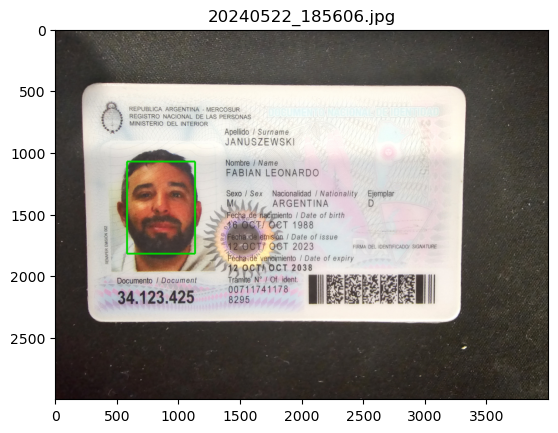


Procesando la imagen: IMG_20170706_112204487.jpg
Se encontró un rostro en IMG_20170706_112204487.jpg. Cuadro dibujado.


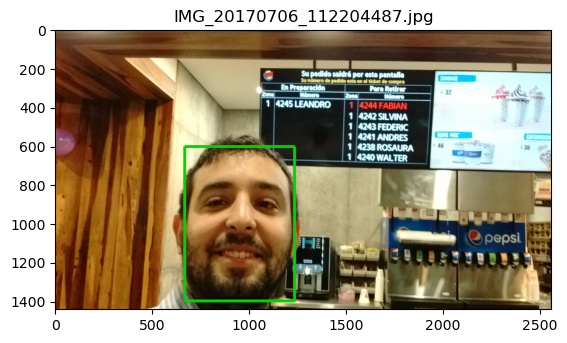


Procesando la imagen: janu_re.png
Se encontró un rostro en janu_re.png. Cuadro dibujado.


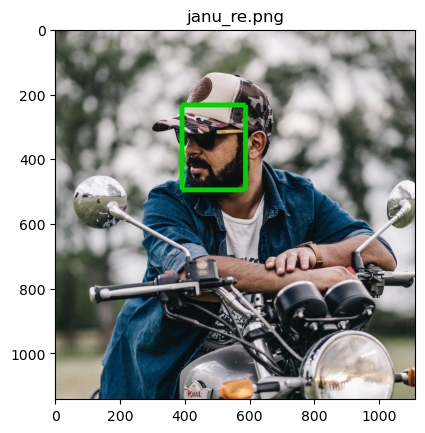


Procesando la imagen: janu_traje.jpg
Se encontró un rostro en janu_traje.jpg. Cuadro dibujado.


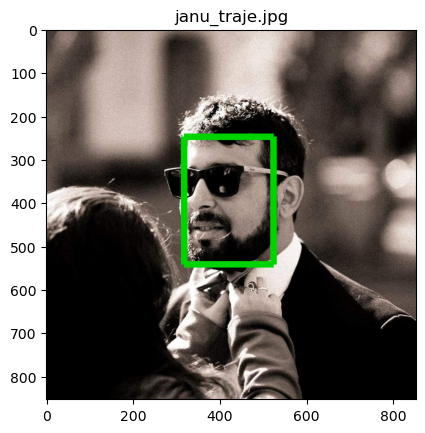

In [45]:
# Iterar sobre todas las imágenes en la carpeta
for targetfilename in image_files:
    targetfilepath = os.path.join(images_folder, targetfilename)
    # Construye la ruta completa de la imagen actual.

    print(f"\nProcesando la imagen: {targetfilename}")
    # Imprime el nombre de la imagen que está siendo procesada.

    targetimage = Image.open(targetfilepath)
    # Abre la imagen actual.

    imgWidth, imgHeight = targetimage.size
    # Obtiene las dimensiones (ancho y alto) de la imagen objetivo en píxeles.

    with open(targetfilepath, 'rb') as timage:
        response2 = client.search_faces_by_image(
            CollectionId=collection_id,
            Image={'Bytes': timage.read()},
            FaceMatchThreshold=threshold,
            MaxFaces=maxFaces
        )
        # Busca coincidencias para la imagen actual.

    if 'SearchedFaceBoundingBox' in response2:
        # Verifica si el BoundingBox está presente en la respuesta.
        box = response2['SearchedFaceBoundingBox']
        # Extrae el BoundingBox del rostro detectado.

        draw = ImageDraw.Draw(targetimage)
        # Crea un objeto `ImageDraw` para permitir dibujar sobre la imagen.

        # Calcula las coordenadas del cuadro en píxeles
        left = imgWidth * box['Left']
        top = imgHeight * box['Top']
        width = imgWidth * box['Width']
        height = imgHeight * box['Height']

        points = ((left, top), (left + width, top), (left + width, top + height), (left, top + height), (left, top))
        # Define los puntos del rectángulo en orden.

        draw.line(points, fill='#00d400', width=15)
        # Dibuja el cuadro verde alrededor del rostro detectado.

        print(f"Se encontró un rostro en {targetfilename}. Cuadro dibujado.")
        # Imprime un mensaje indicando que el cuadro fue dibujado.

        plt.imshow(targetimage)
        plt.title(targetfilename)
        plt.show()
        # Muestra la imagen con el cuadro dibujado.
    else:
        print(f"No se encontraron rostros en la imagen: {targetfilename}")
        # Mensaje en caso de que no se detecten rostros.


## Tarea 8: eliminar la colección

Cuando finalice, elimine la colección. Para ello, ejecute el siguiente código: 


In [46]:
print('Attempting to delete collection ' + collection_id)
# Imprime un mensaje indicando que se intentará eliminar la colección especificada.

status_code = 0
# Inicializa la variable para almacenar el código de estado de la operación.

try:
    # Bloque try para intentar eliminar la colección y manejar posibles errores.
    response = client.delete_collection(CollectionId=collection_id)
    # Llama a la API `delete_collection` para eliminar la colección con el ID especificado.
    status_code = response['StatusCode']
    # Obtiene el código de estado de la respuesta para confirmar el resultado.
    print('All done!')
    # Imprime un mensaje indicando que la colección se eliminó exitosamente.
    print(status_code)
    # Imprime el código de estado para confirmar la operación.

except ClientError as e:
    # Maneja posibles errores ocurridos durante la eliminación de la colección.
    if e.response['Error']['Code'] == 'ResourceNotFoundException':
        # Verifica si el error indica que la colección no fue encontrada.
        print('The collection ' + collection_id + ' was not found ')
        # Imprime un mensaje indicando que la colección no existe.
    else:
        # Maneja otros errores que no sean de tipo "colección no encontrada".
        print('Error other than Not Found occurred: ' + e.response['Error']['Message'])
        # Imprime el mensaje del error devuelto por AWS Rekognition.
    status_code = e.response['ResponseMetadata']['HTTPStatusCode']
    # Establece el código de estado según el error devuelto.


Attempting to delete collection Collection
All done!
200


# ¡Felicitaciones!

Completó este laboratorio y ahora puede finalizarlo siguiendo las instrucciones en la guía del laboratorio.